### Exercises

#### Exercise 1

##### Part 1

Read in the dataset in `fuel.csv`. Inspect the distribution of the response variable `fuel_consumption`.

<Axes: xlabel='fuel_consumption', ylabel='Count'>

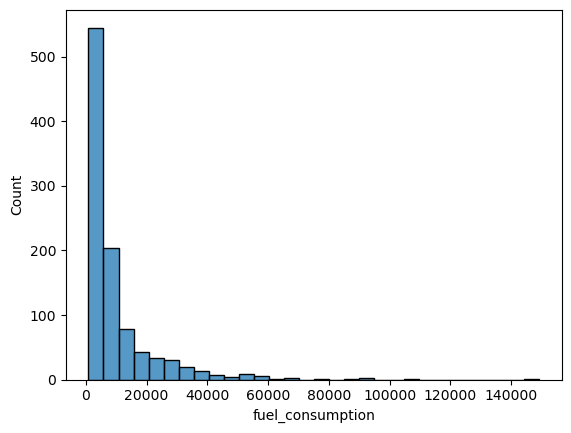

In [89]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv("../data/fuel.csv")

sns.histplot(data=df, x="fuel_consumption", bins=30)

The fuel consumption distribution is highly right skewed with the lower fuel consumption having hte highest count of airplanes

##### Part 2

Determine whether a transformation should be applied to the response to make its distribution appear more normal. Apply that transformation and then inspect the distribution of the transformed response variable.

The distribution is normalized right skewed ranging from 6.5 to 12 highest count around 7.5 to 9.5

<Axes: xlabel='log_fuel_consumption', ylabel='Count'>

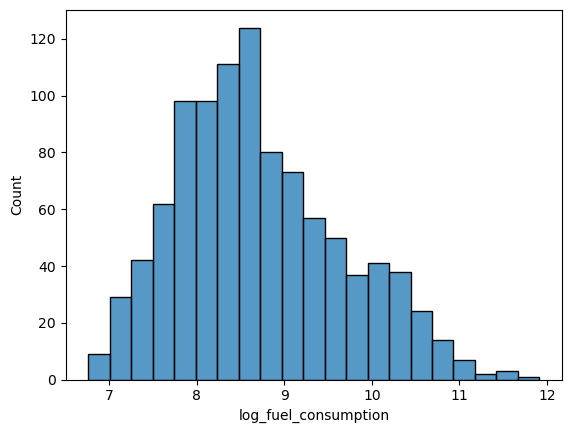

In [90]:
df["log_fuel_consumption"] = np.log(df["fuel_consumption"]+1)

sns.histplot(data=df, x="log_fuel_consumption")

#### Exercise 2

##### Part 1

Select a quantitative predictor that you believe would be useful in modeling the response variable. Provide a numeric summary or visualization to justify this choice.

<Axes: xlabel='flight_distance', ylabel='log_fuel_consumption'>

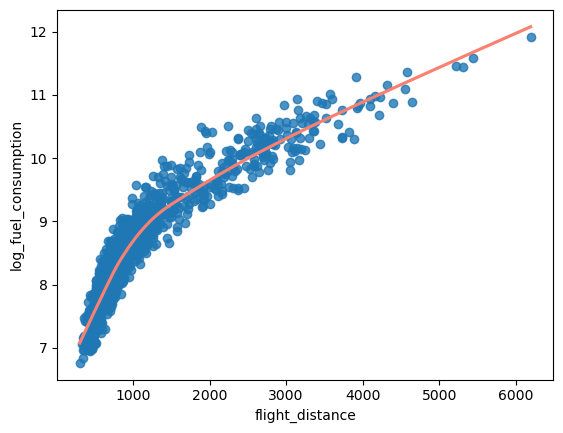

In [91]:
sns.regplot(data=df, x="flight_distance", y="log_fuel_consumption", lowess=True, line_kws={"color": "Salmon"})

##### Part 2

Determine if a transformation should be applied to the predictor to achieve a more linear relationship between the response and the predictor. If a transformation is necessary, apply the transformation and provide another summary or visualization to demonstrate the effect of this transformation.

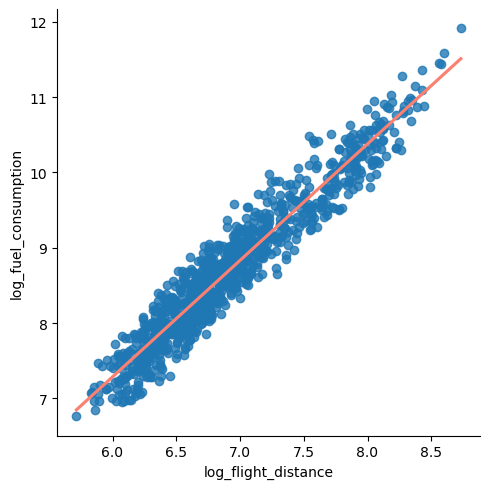

In [92]:
df["log_flight_distance"] = np.log(df["flight_distance"])

sns.lmplot(data=df, x="log_flight_distance", y="log_fuel_consumption", ci=False, line_kws={"color": "salmon"})

#### Exercise 3

##### Part 1

Use the `sklearn` library to fit a simple linear regression model using your predictor and response variable. Output the intercept and slope of the fitted model.

In [93]:
from sklearn.linear_model import LinearRegression 

slr_model = LinearRegression()

x_slr = df[["log_flight_distance"]]
y = df["log_fuel_consumption"]

slr_model.fit(x_slr,y)

print("Intercept:", slr_model.intercept_)
print("Slope:", slr_model.coef_)

Intercept: -1.9992891484535686
Slope: [1.54735112]


##### Part 2

Write out the regression equation for the fitted model and interpret the intercept and slope in context.

log_fuel_consumption = 1.5474 * (log_flight_distance) - 1.9993

#### Exercise 4

##### Part 1

Investigate relationships with other quantitative variables and the response. Identify several other quantitative variables you could include in your model. Provide a numeric summary or visualization justifying these choices.

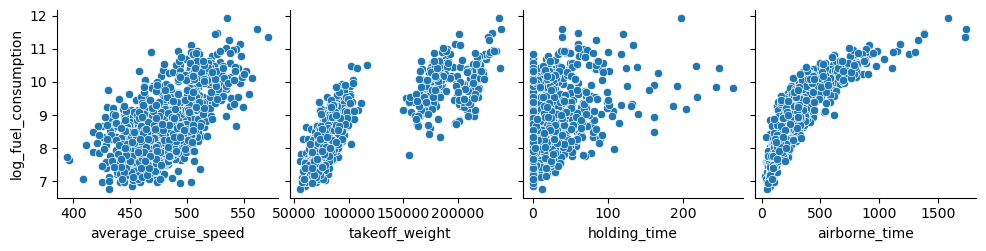

In [94]:
sns.pairplot(data=df, x_vars=["average_cruise_speed", "takeoff_weight", "holding_time", "airborne_time"], y_vars=["log_fuel_consumption"])



##### Part 2

Use the `sklearn` library to fit a multiple linear regression model with the other selected quantitative variables. Output the intercept and slope coefficients.

In [95]:
mlr_model = LinearRegression()

x_mlr = df[["average_cruise_speed", "takeoff_weight", "holding_time", "airborne_time"]]

mlr_model.fit(x_mlr, y)

print("Intercept:", mlr_model.intercept_)
print("Slope:", mlr_model.coef_)

Intercept: 4.995070373278979
Slope: [4.68680718e-03 7.79246958e-06 6.90395285e-03 1.80047405e-03]


##### Part 3

Write out the full regression equation for your model. Interpret each of the coefficients for your fitted model in context.

Log_fuel_consumption = 4.9950 + 4.6868-03*(average_cruise_speed) + 7.7925-06*(takeoff_weight) + 6.9040-03*(log_holding_time) + 1.8005-03*(log_airborne_time)

#### Exercise 5

##### Part 1

Identify one or more categorical variables that could be useful in predicting the response variable. Provide a numeric summary or visualization to justify these choices of categorical variables.

<Axes: xlabel='weather_condition', ylabel='log_fuel_consumption'>

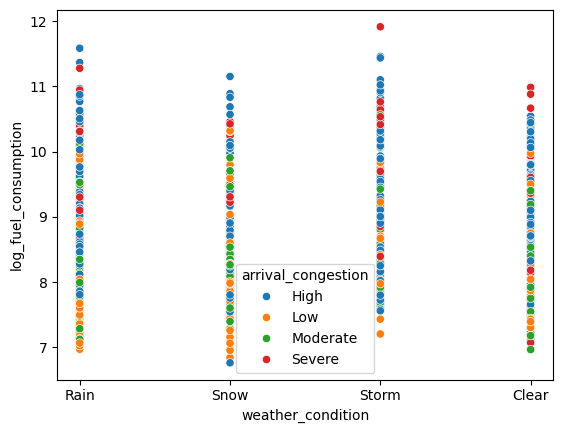

In [96]:
sns.scatterplot(data=df, x="weather_condition", y="log_fuel_consumption", hue="arrival_congestion")

##### Part 2

Use the `sklearn` library to fit a multiple linear regression model including the selected categorical variables and any relevant quantitative variables. Output the intercept and slope coefficients.

In [97]:
df = pd.get_dummies(data=df, columns=["arrival_congestion"], drop_first=True, dtype="int")
df.head()

,season,departure_airport,weather_condition,cloud_type,jet_stream_region,aircraft_type,upholstery_style,engine_model,manufacturer_country,terminal_architecture,...,cabin_pressurization_setting,scheduled_arrival_buffer,departure_runways,meal_services,fuel_consumption,log_fuel_consumption,log_flight_distance,arrival_congestion_Low,arrival_congestion_Moderate,arrival_congestion_Severe
0,Summer,SEA,Rain,Cumulus,No Significant Jet,A320,Leather,CFM56,Consortium,Classic Terminal,...,7722.632019,30.388906,3,2,10615.616467,9.270176,6.897102,0,0,0
1,Spring,LAX,Rain,Stratus,Polar Jet,B737,Leather,LEAP-1A,Consortium,Classic Terminal,...,7422.808758,29.388303,4,3,11139.487861,9.318341,7.314453,0,0,0
2,Winter,SEA,Snow,Stratus,Polar Jet,B737,Leather,LEAP-1A,Consortium,Concrete Hub,...,7538.383539,26.912105,1,3,12758.987244,9.454070,7.225428,0,0,0
3,Fall,ATL,Snow,Cumulus,Polar Jet,B737,Leather,CFM56,Consortium,Classic Terminal,...,7673.083469,5.875993,1,0,1847.805814,7.522295,6.275059,1,0,0
4,Summer,LAX,Storm,Cumulonimbus,Subtropical Jet,B737,Leather,LEAP-1A,France,Classic Terminal,...,7564.882455,31.684231,4,3,15866.554498,9.672032,7.394280,0,1,0


In [98]:
cat_model = LinearRegression()

x_cat = df[["average_cruise_speed", "takeoff_weight", "holding_time", "airborne_time","arrival_congestion_Low", "arrival_congestion_Moderate", "arrival_congestion_Severe"]]

cat_model.fit(x_cat, y)

print("Intercept:", cat_model.intercept_)
print("Slope:", cat_model.coef_)

Intercept: 4.2882186094034385
Slope: [ 6.64771535e-03  7.43333622e-06  5.21723432e-03  1.65368439e-03
 -3.62685720e-01 -1.87868468e-01  8.24451956e-02]


##### Part 3

Write out the full regression equation for your model. Interpret each of the coefficients for your fitted model in context.

log_fuel_consumption = 4.2882 + 6.6477-038*(average_cruise_speed) + 7.4333-068*(takeoff_weight) + 5.2172-038*(holding_time) + 1.6537-03*(airborne_time) - 3.6269-01*(arrival_congestion_Low) - 1.8787-01*(arrival_congestion_Moderate) + 8.2445-02*(arrival_congestion_Severe)

#### Exercise 6

##### Part 1

Compute RMSE and $R^2$ for all of the previously fitted models.

In [99]:
from sklearn.metrics import root_mean_squared_error, r2_score

slr_pred = slr_model.predict(x_slr)
mlr_pred = mlr_model.predict(x_mlr)
cat_pred = cat_model.predict(x_cat)

print("SLR RMSE:", root_mean_squared_error(slr_pred, y))
print("MLR RMSE:", root_mean_squared_error(mlr_pred, y))
print("CAT RMSE:", root_mean_squared_error(cat_pred, y))

print("SLR R2:", r2_score(slr_pred, y))
print("MLR R2:", r2_score(mlr_pred, y))
print("CAT R2:", r2_score(cat_pred, y))
      

SLR RMSE: 0.26512110452488713
MLR RMSE: 0.3354918455130043
CAT RMSE: 0.3052610739681967
SLR R2: 0.914809085709446
MLR R2: 0.8562175440602431
CAT R2: 0.883836645490567


##### Part 2

Keeping in mind that we want to find models that have high predictive power, but are relatively simple, which of the competing models would you select?

I would choose single linear regression model because it has the highest R2(.2651) with the corresponding lower RSME(.9148)

#### Exercise 7

##### Part 1

Produce a numeric summary or visualization that allows you to investigate any instances of multicollinearity.

<Axes: xlabel='log_airborne_time', ylabel='log_flight_distance'>

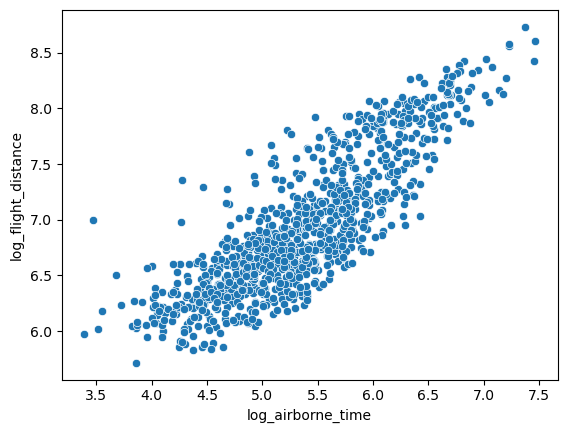

In [100]:
df["log_airborne_time"] = np.log(df["airborne_time"])
sns.scatterplot(data=df, x="log_airborne_time", y="log_flight_distance")

##### Part 2

Describe any instances of multicollinearity that you discovered.

I found multicollinearity between airborne time and flight distance as the scatterplot shows a strong positive linear relationship.

#### Exercise 8


##### Part 1

Create a plot of the fitted values $\hat{y}_i$ versus the residuals $y_i - \hat{y}_i$.

Text(0, 0.5, 'Residuals')

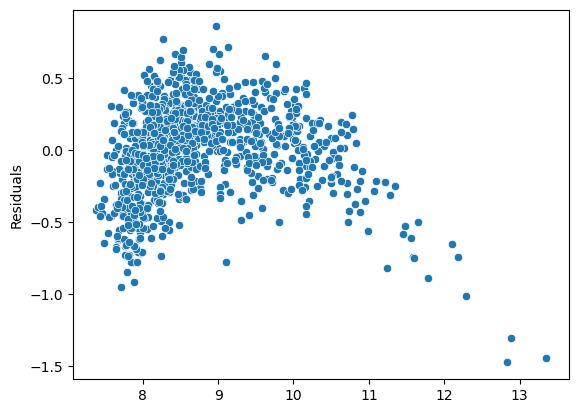

In [101]:
resids = y - cat_pred

sns.scatterplot(data=df, x=cat_pred, y=resids).set_ylabel("Residuals")

##### Part 2

Using the plot of fitted values versus residuals, do there appear to be any violations of the assumption of linearity?

Yes, there appears to be a violation of linearity because the residuals follow a curved pattern instead of being randomly scattered.

#### Exercise 9

##### Part 1

Plot the residuals $y_i-\hat{y}_i$ against other potentially useful predictors that haven't already been included in the model.

Text(0, 0.5, 'Residuals')

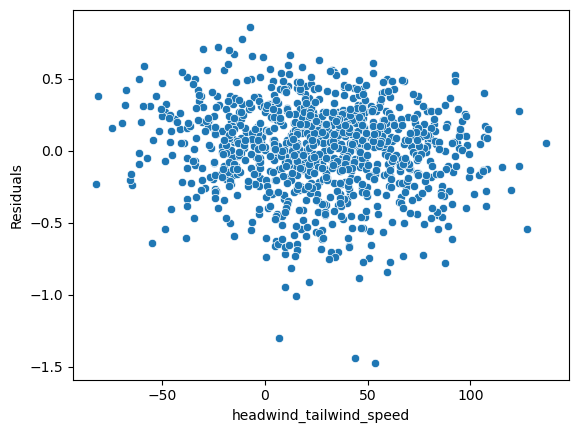

In [102]:
sns.scatterplot(data=df, x="headwind_tailwind_speed", y=resids).set_ylabel("Residuals")

##### Part 2

Based on the plots of residuals versus other predictors, do their appear to be any other predictors that should be included in the model?

No, headwind_tailwind_speed should not be included in the model because the residuals sdoes not show a noticeable pattern, suggesting no clear pattern.

#### Exercise 10

##### Part 1

Using everything you've learned so far, fit a final model that you would use to predict the response. Report the intercept and coefficients for this final model.

In [103]:
slr_model = LinearRegression()

x_slr = df[["log_flight_distance"]]
slr_model.fit(x_slr,y)

print("Intercept:", slr_model.intercept_)
print("Slope:", slr_model.coef_)

Intercept: -1.9992891484535686
Slope: [1.54735112]


I selected the simple linear regression model using log_flight_distance because it achieved the highest R² value and the lowest RMSE among the models considered, while also being the simplest model to interpret.

##### Part 2

Report the regression equation for your final model.

log_fuel_consumption = 1.5474 * (log_flight_distance) - 1.9993